In [6]:
import pandas as pd
import gymnasium as gym
import gym_anytrading
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
import matplotlib.pyplot as plt

In [7]:
# 1. Load and format the data
df = pd.read_csv('./individual_stocks_5yr/AAL_data.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print("Data loaded successfully!")
print(df.head())

Data loaded successfully!
             open   high    low  close    volume Name
date                                                 
2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL


In [8]:
# Rename columns to match gym-anytrading expectations**
df = df.rename(columns={
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume'
})

# Remove any rows with missing values
df = df.dropna()

print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Data shape: (1259, 6)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Name']

First few rows:
             Open   High    Low  Close    Volume Name
date                                                 
2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL


In [9]:
# 2. Define the environment
# window_size: How many past days the agent looks at to make a decision (the "State")
window_size = 15
start_index = window_size
end_index = len(df) # We will train on the whole dataset for this example

# Create the environment using gym-anytrading
env_maker = lambda: gym.make(
    'stocks-v0',
    df=df,
    frame_bound=(start_index, end_index),
    window_size=window_size
)

# Stable Baselines requires vectorized environments
env = DummyVecEnv([env_maker])

In [10]:
# Initialize the Deep Q-Network Model
# 'MlpPolicy' means it uses a standard Multi-Layer Perceptron (Neural Network)
model = DQN(
    'MlpPolicy', 
    env, 
    verbose=1, 
    learning_rate=0.001,
    buffer_size=10000, 
    exploration_fraction=0.1, # It will explore randomly for the first 10% of training
    exploration_final_eps=0.02
)

Using cpu device


In [ ]:
# Train the Agent
print("Starting training...")
# total_timesteps is how many days the agent will experience. 
# 100,000 means it will play through your 1,260-day dataset about 80 times.
model.learn(total_timesteps=100000) 
print("Training finished!")

Starting training...


In [24]:

#Evaluate the trained model
# We create a new, single environment for testing
test_env = gym.make(
    'stocks-v0', 
    df=df, 
    frame_bound=(start_index, end_index), 
    window_size=window_size
)

observation, info = test_env.reset()
done = False
truncated = False

while not (done or truncated):
    # The agent predicts the best action (0 or 1) based on the current window of prices
    action, _states = model.predict(observation, deterministic=True)
    
    # We take the action in the environment
    observation, reward, done, truncated, info = test_env.step(action)

# Print final stats
print("Total Profit: ", info['total_profit'])
print("Total Reward: ", info['total_reward'])

Total Profit:  0.10523305
Total Reward:  4.790084


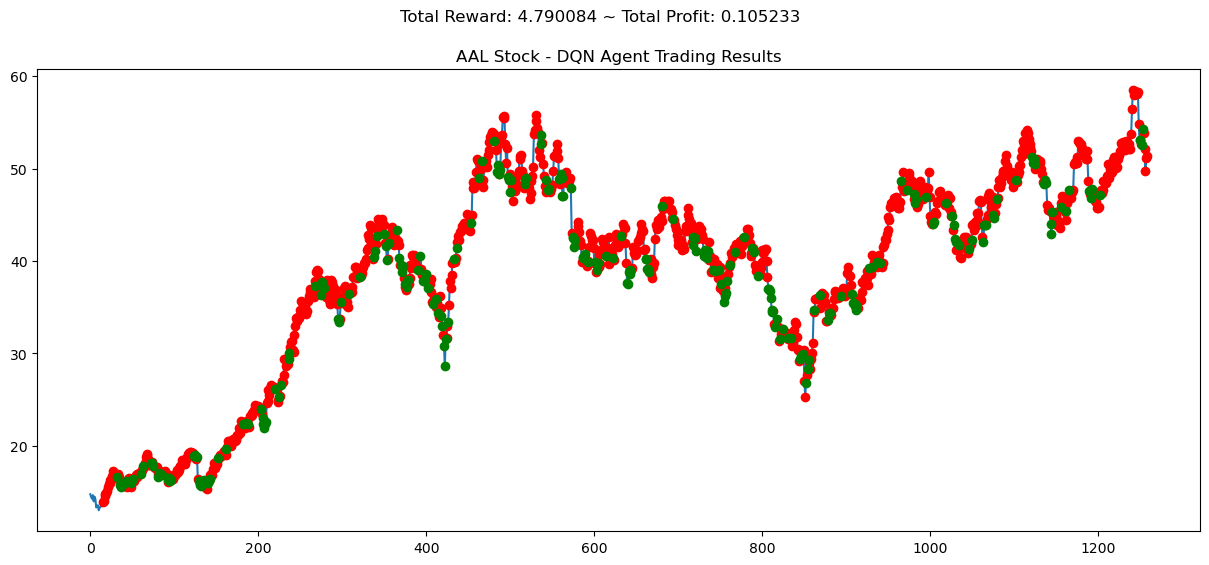

In [25]:

# Plot the results
plt.figure(figsize=(15, 6))
plt.cla()
test_env.unwrapped.render_all()
plt.title("AAL Stock - DQN Agent Trading Results")
plt.show()